In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
import seaborn as sns

In [5]:
df = pd.read_csv("..\datasets\spotify_processed.csv", encoding='utf-8', low_memory=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Allan\AppData\Local\Temp\ipykernel_7424\4071135716.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\datasets\spotify_processed.csv", encoding='utf-8', low_memory=True)


In [11]:
CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo'
]
X = df[CLUSTER_FEATURES]

# PCA

Definindo N componentes , mantendo a variância.

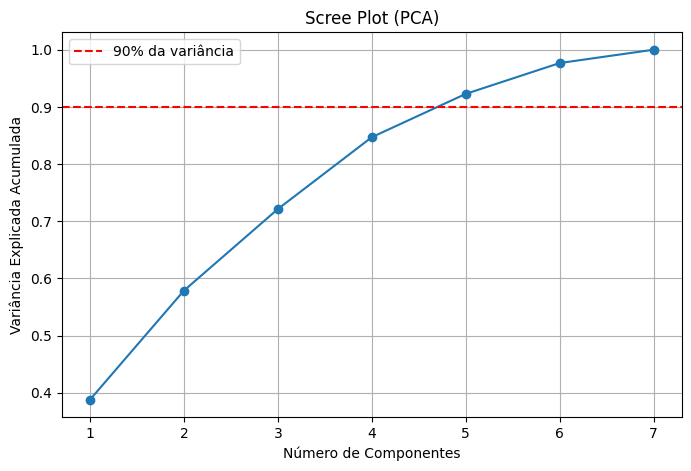

In [12]:
pca = PCA()
X_pca = pca.fit_transform(X)


explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% da variância')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Scree Plot (PCA)')
plt.grid(True)
plt.legend()
plt.show()

In [13]:
pca_final = PCA(n_components=5)
X_pca_final = pca_final.fit_transform(X)
df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(X_pca_final.shape[1])])


# Kmeans

In [14]:
kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(X_pca_final)

df_pca['cluster'] = clusters
print(df_pca['cluster'].value_counts())

cluster
3    21308
2    17413
6    16181
0    12813
1     7615
4     5084
5      930
Name: count, dtype: int64


In [15]:
scaler = joblib.load('..\modelos\standard_scaler.joblib')
reverse = ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo' ]
df[reverse] = scaler.inverse_transform(df[reverse])



<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Allan\AppData\Local\Temp\ipykernel_7424\3675984619.py:1: SyntaxWarning: invalid escape sequence '\m'
  scaler = joblib.load('..\modelos\standard_scaler.joblib')


In [16]:
df = df.reset_index(drop=True)
df_pca = df_pca.reset_index(drop=True)
df_cluster = pd.concat([df, df_pca], axis=1)

df_cluster.to_csv('..\datasets\df_cluster.csv', index=False)


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Allan\AppData\Local\Temp\ipykernel_7424\3293713209.py:5: SyntaxWarning: invalid escape sequence '\d'
  df_cluster.to_csv('..\datasets\df_cluster.csv', index=False)


# DBSCAN

In [9]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X_pca_final)

outliers = X[labels == -1]
print(f"Total de outliers detectados: {len(outliers)}")

Total de outliers detectados: 467
